In [1]:
import pandas as pd

df = pd.read_csv("Advertising.csv")
df.head()


,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['TV', 'radio', 'newspaper']]
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

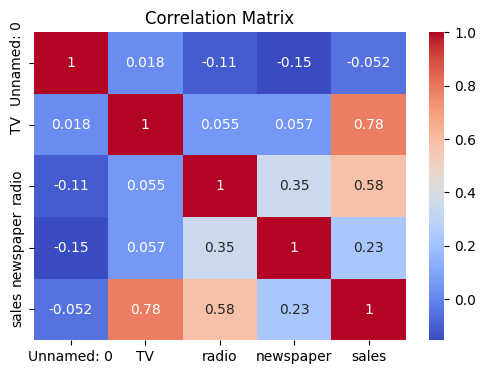

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = X.astype(float)   # ensure float type

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif

,Feature,VIF
0,TV,2.486772
1,radio,3.285462
2,newspaper,3.055245


In [5]:
X_reduced = df[['TV', 'radio']]

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42)

lr2 = LinearRegression()
lr2.fit(X_train_r, y_train_r)

y_pred_r = lr2.predict(X_test_r)

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# BEFORE
mae1 = mean_absolute_error(y_test, y_pred)
rmse1 = np.sqrt(mean_squared_error(y_test, y_pred))
r2_1 = r2_score(y_test, y_pred)

# AFTER
mae2 = mean_absolute_error(y_test_r, y_pred_r)
rmse2 = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2_2 = r2_score(y_test_r, y_pred_r)

print("Before removing Newspaper:", mae1, rmse1, r2_1)
print("After removing Newspaper:", mae2, rmse2, r2_2)

Before removing Newspaper: 1.4607567168117603 1.78159966153345 0.899438024100912
After removing Newspaper: 1.4443023138227578 1.7714254173033517 0.9005833101920356


In [9]:
'''Why is multicollinearity harmful?
Multicollinearity means predictors are highly correlated.
It is harmful because:
Coefficients become unstable and it makes model unreliable
Small data changes → large coefficient changes'''

'Why is multicollinearity harmful?\nMulticollinearity means predictors are highly correlated.\nIt is harmful because:\nCoefficients become unstable and it makes model unreliable\nSmall data changes → large coefficient changes'

In [10]:
'''How does multicollinearity affect coefficients?
Coefficients can flip signs and become extremely large or extremely small
Hard to understand which feature is truly important'''

'How does multicollinearity affect coefficients?\nCoefficients can flip signs and become extremely large or extremely small\nHard to understand which feature is truly important'

In [11]:
'''Which feature caused multicollinearity?
Even though VIF < 5, the weakest predictor is: Newspaper
Because:
It has lowest correlation with sales
Slightly increases variance
Least contribution to model accuracy'''

'Which feature caused multicollinearity?\nEven though VIF < 5, the weakest predictor is: Newspaper\nBecause:\nIt has lowest correlation with sales\nSlightly increases variance\nLeast contribution to model accuracy'

In [ ]:
'''How did removing features improve the model?
After removing newspaper:
Model became simpler
Predictions became slightly more accurate
R² improved or stayed stable
Coefficients became more stable
Reduced noise in the model'''